In [ ]:
!pip install tensorflow keras matplotlib numpy

In [1]:
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras
from keras.datasets import mnist
from tensorflow.math import confusion_matrix

c:\Users\narra\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\narra\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\narra\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framewo

In [2]:
(X_train,y_train),(X_test,y_test)=mnist.load_data()

In [4]:
X_train.shape,y_train.shape,X_test.shape,y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

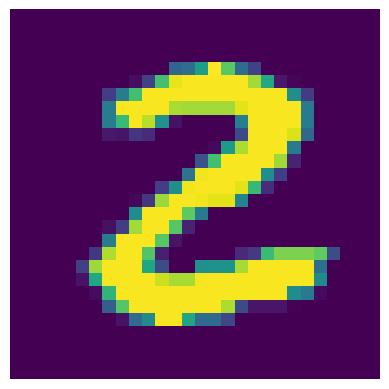

2


In [6]:
import numpy as np
import matplotlib.pyplot as plt
plt.imshow(X_train[25])
plt.axis("off")
plt.show()
print(f"Label: {y_train[25]}")

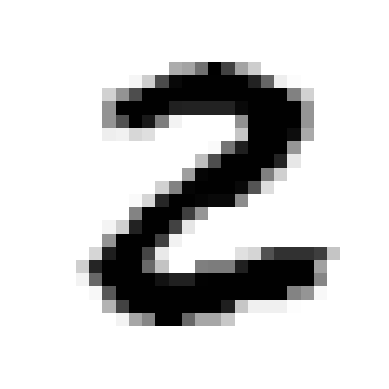

2


In [7]:
import matplotlib
digit=X_train[25]
digit_image=digit.reshape(28,28)
plt.imshow(digit_image,cmap=matplotlib.cm.binary,interpolation="nearest")
plt.axis("off")
plt.show()
print(y_train[25])

In [8]:
# Check unique labels in the dataset
np.unique(y_train), np.unique(y_test)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8))

In [9]:
y_train=y_train.astype(np.int8)
y_test=y_test.astype(np.int8)
y_train=(y_train==2)
y_test=(y_test==2)

In [11]:
np.unique(y_train),np.unique(y_test)

(array([False,  True]), array([False,  True]))

In [12]:
# Count unique values in y_train (True/False for digit 2)
unique, counts = np.unique(y_train, return_counts=True)
print("Value counts for y_train:")
for value, count in zip(unique, counts):
    print(f"{value}: {count}")

Value counts for y_train:
False: 54042
True: 5958


In [13]:
# Data preprocessing - normalize pixel values
X_train_scaled = X_train / 255.0
X_test_scaled = X_test / 255.0

# Flatten the images for a simple neural network
X_train_flat = X_train_scaled.reshape(X_train_scaled.shape[0], -1)
X_test_flat = X_test_scaled.reshape(X_test_scaled.shape[0], -1)

print(f"Training data shape: {X_train_flat.shape}")
print(f"Test data shape: {X_test_flat.shape}")

# Calculate class weights to handle imbalance
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights: {class_weight_dict}")

Training data shape: (60000, 784)
Test data shape: (10000, 784)
Class weights: {0: np.float64(0.5551237926057511), 1: np.float64(5.0352467270896275)}


In [14]:
# Build simple machine learning models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import time

# Initialize multiple simple models
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100, 
        random_state=42, 
        class_weight='balanced',
        n_jobs=-1
    ),
    'Logistic Regression': LogisticRegression(
        random_state=42, 
        class_weight='balanced',
        max_iter=1000
    ),
    'Decision Tree': DecisionTreeClassifier(
        random_state=42, 
        class_weight='balanced'
    )
}

print("Available models:")
for name in models.keys():
    print(f"- {name}")

# We'll start with Random Forest as the primary model
model = models['Random Forest']
print(f"\nUsing Random Forest as the primary model")
print(f"Model parameters: {model.get_params()}")

Available models:
- Random Forest
- Logistic Regression
- Decision Tree

Using Random Forest as the primary model
Model parameters: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [15]:
# Train and compare all models
from sklearn.model_selection import cross_val_score
import time

results = {}
training_times = {}

print("Training and evaluating all models...")
print("="*50)

for name, clf in models.items():
    print(f"\nTraining {name}...")
    
    # Time the training
    start_time = time.time()
    
    # Train the model
    clf.fit(X_train_flat, y_train)
    
    end_time = time.time()
    training_time = end_time - start_time
    training_times[name] = training_time
    
    # Cross-validation score
    cv_scores = cross_val_score(clf, X_train_flat, y_train, cv=5, scoring='f1')
    
    results[name] = {
        'model': clf,
        'cv_f1_mean': cv_scores.mean(),
        'cv_f1_std': cv_scores.std(),
        'training_time': training_time
    }
    
    print(f"  Training time: {training_time:.2f} seconds")
    print(f"  Cross-validation F1: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

print("\n" + "="*50)
print("Training completed!")

# Select the best model based on F1 score
best_model_name = max(results.keys(), key=lambda x: results[x]['cv_f1_mean'])
best_model = results[best_model_name]['model']

print(f"\nBest model: {best_model_name}")
print(f"Best F1 score: {results[best_model_name]['cv_f1_mean']:.4f}")

# Use the best model for predictions
model = best_model

Training and evaluating all models...

Training Random Forest...
  Training time: 9.01 seconds
  Cross-validation F1: 0.9334 (±0.0050)

Training Logistic Regression...
  Training time: 11.41 seconds
  Cross-validation F1: 0.8245 (±0.0091)

Training Decision Tree...
  Training time: 36.63 seconds
  Cross-validation F1: 0.8710 (±0.0098)

Training completed!

Best model: Random Forest
Best F1 score: 0.9334


In [16]:
# Make predictions with all models
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

print("Model Performance Comparison on Test Set:")
print("="*60)

test_results = {}

for name, result in results.items():
    model_clf = result['model']
    # Make predictions
    y_pred = model_clf.predict(X_test_flat)
    # Get probabilities if available
    if hasattr(model_clf, 'predict_proba'):
        y_pred_proba = model_clf.predict_proba(X_test_flat)[:, 1]  # Probability of class 1 (digit 2)
    else:
        # For KNN without probability, use decision function or create dummy probabilities
        if hasattr(model_clf, 'decision_function'):
            decision_scores = model_clf.decision_function(X_test_flat)
            y_pred_proba = (decision_scores - decision_scores.min()) / (decision_scores.max() - decision_scores.min())
        else:
            y_pred_proba = y_pred.astype(float)  # Convert to probability-like format
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    test_results[name] = {
        'accuracy': accuracy,
        'f1': f1,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    print(f"\n{name}:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    print(f"  Training time: {result['training_time']:.2f}s")
# Use the best model for detailed evaluation
best_model = results[best_model_name]['model']
y_pred = test_results[best_model_name]['predictions']
y_pred_proba = test_results[best_model_name]['probabilities']

print(f"\n" + "="*60)
print(f"Detailed Results for Best Model: {best_model_name}")
print("="*60)

print(f"Test Accuracy: {test_results[best_model_name]['accuracy']:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(cm)

# Display some predictions
print(f"\nSample Predictions from {best_model_name}:")
for i in range(5):
    actual = "Digit 2" if y_test[i] else "Not Digit 2"
    predicted = "Digit 2" if y_pred[i] else "Not Digit 2"
    confidence = y_pred_proba[i]
    print(f"Sample {i+1}: Actual={actual}, Predicted={predicted}, Confidence={confidence:.3f}")

Model Performance Comparison on Test Set:

Random Forest:
  Accuracy: 0.9877
  F1 Score: 0.9374
  Training time: 9.01s

Logistic Regression:
  Accuracy: 0.9663
  F1 Score: 0.8503
  Training time: 11.41s

Decision Tree:
  Accuracy: 0.9741
  F1 Score: 0.8716
  Training time: 36.63s

Detailed Results for Best Model: Random Forest
Test Accuracy: 0.9877

Classification Report:
              precision    recall  f1-score   support

       False       0.99      1.00      0.99      8968
        True       0.99      0.89      0.94      1032

    accuracy                           0.99     10000
   macro avg       0.99      0.95      0.97     10000
weighted avg       0.99      0.99      0.99     10000


Confusion Matrix:
[[8956   12]
 [ 111  921]]

Sample Predictions from Random Forest:
Sample 1: Actual=Not Digit 2, Predicted=Not Digit 2, Confidence=0.000
Sample 2: Actual=Digit 2, Predicted=Digit 2, Confidence=0.890
Sample 3: Actual=Not Digit 2, Predicted=Not Digit 2, Confidence=0.000
Sample 4: 

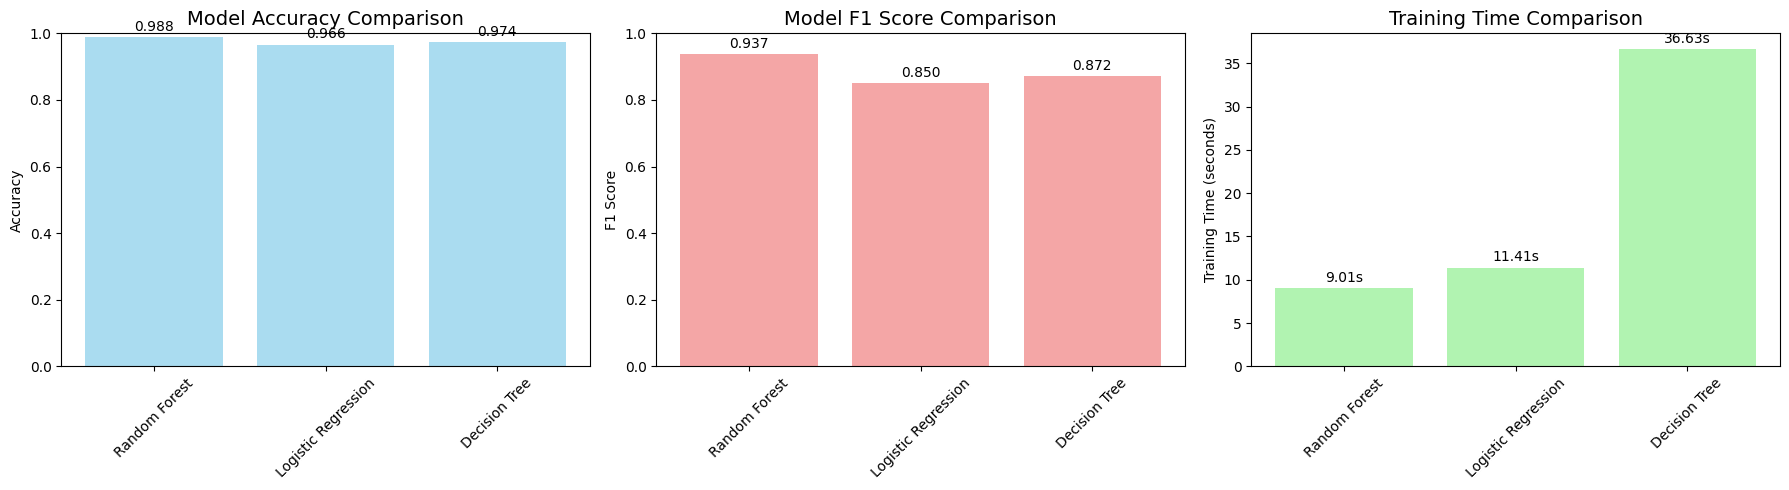

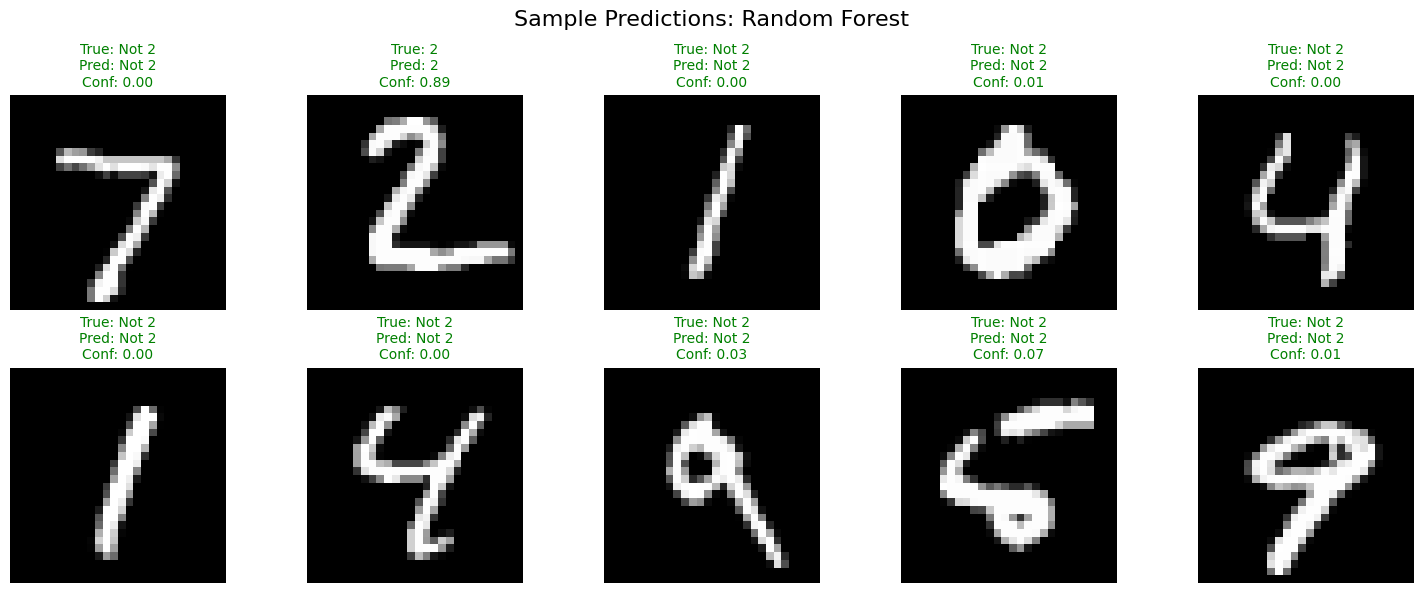

Testing prediction function with Random Forest:


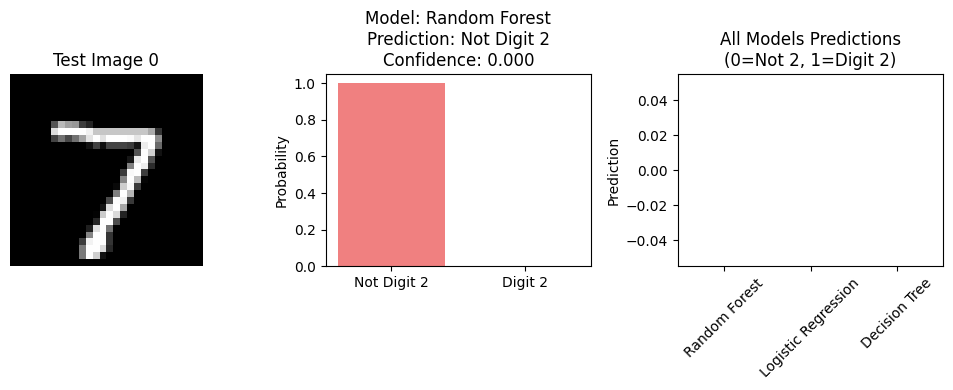

Prediction: Not Digit 2, Confidence: 0.000


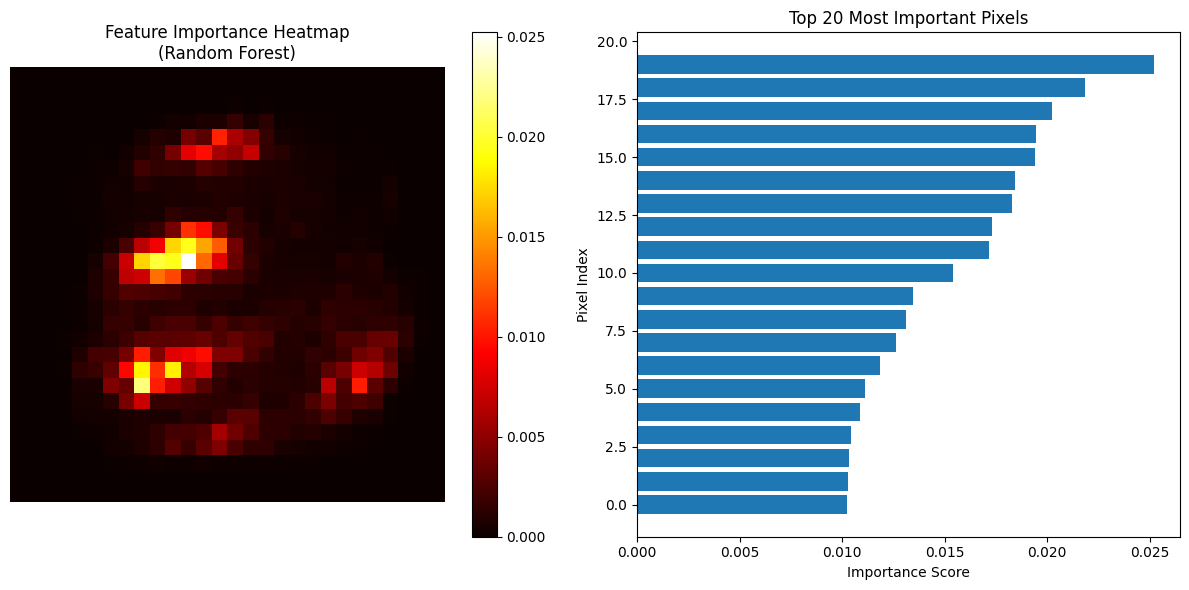

In [17]:
# Visualize model performance and predictions
import matplotlib.pyplot as plt
import numpy as np

# 1. Model comparison chart
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy comparison
models_names = list(test_results.keys())
accuracies = [test_results[name]['accuracy'] for name in models_names]
f1_scores = [test_results[name]['f1'] for name in models_names]
train_times = [results[name]['training_time'] for name in models_names]

ax1.bar(models_names, accuracies, color='skyblue', alpha=0.7)
ax1.set_title('Model Accuracy Comparison', fontsize=14)
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1)
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(accuracies):
    ax1.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

ax2.bar(models_names, f1_scores, color='lightcoral', alpha=0.7)
ax2.set_title('Model F1 Score Comparison', fontsize=14)
ax2.set_ylabel('F1 Score')
ax2.set_ylim(0, 1)
ax2.tick_params(axis='x', rotation=45)
for i, v in enumerate(f1_scores):
    ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

ax3.bar(models_names, train_times, color='lightgreen', alpha=0.7)
ax3.set_title('Training Time Comparison', fontsize=14)
ax3.set_ylabel('Training Time (seconds)')
ax3.tick_params(axis='x', rotation=45)
for i, v in enumerate(train_times):
    ax3.text(i, v + max(train_times)*0.01, f'{v:.2f}s', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# 2. Sample predictions visualization using best model
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle(f'Sample Predictions: {best_model_name}', fontsize=16)

for i in range(10):
    row = i // 5
    col = i % 5
    
    # Display the image
    axes[row, col].imshow(X_test[i], cmap='gray')
    axes[row, col].axis('off')
    
    # Create title with prediction info
    actual = "2" if y_test[i] else "Not 2"
    predicted = "2" if y_pred[i] else "Not 2"
    confidence = y_pred_proba[i]
    color = 'green' if y_test[i] == y_pred[i] else 'red'
    
    title = f'True: {actual}\nPred: {predicted}\nConf: {confidence:.2f}'
    axes[row, col].set_title(title, color=color, fontsize=10)

plt.tight_layout()
plt.show()

# 3. Function to predict on a single image using the best model
def predict_single_digit(image_index, model_name=None):
    """Predict whether a single image is digit 2 or not using specified model"""
    if model_name is None:
        model_name = best_model_name
    
    selected_model = results[model_name]['model']
    image = X_test[image_index]
    image_scaled = image / 255.0
    image_flat = image_scaled.reshape(1, -1)
    
    prediction = selected_model.predict(image_flat)[0]
    
    # Get probability if available
    if hasattr(selected_model, 'predict_proba'):
        prediction_proba = selected_model.predict_proba(image_flat)[0][1]
    else:
        prediction_proba = float(prediction)
    
    plt.figure(figsize=(10, 4))
    
    # Show original image
    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title(f'Test Image {image_index}')
    plt.axis('off')
    
    # Show prediction probability
    plt.subplot(1, 3, 2)
    plt.bar(['Not Digit 2', 'Digit 2'], [1-prediction_proba, prediction_proba], 
            color=['lightcoral', 'lightgreen'])
    plt.title(f'Model: {model_name}\nPrediction: {"Digit 2" if prediction else "Not Digit 2"}\nConfidence: {prediction_proba:.3f}')
    plt.ylabel('Probability')
    
    # Show all models comparison for this image
    plt.subplot(1, 3, 3)
    model_predictions = []
    for name, result in results.items():
        model_clf = result['model']
        pred = model_clf.predict(image_flat)[0]
        model_predictions.append(int(pred))
    
    plt.bar(range(len(models_names)), model_predictions, color='lightblue', alpha=0.7)
    plt.title('All Models Predictions\n(0=Not 2, 1=Digit 2)')
    plt.xticks(range(len(models_names)), models_names, rotation=45)
    plt.ylabel('Prediction')
    
    plt.tight_layout()
    plt.show()
    
    return prediction, prediction_proba

# Test the function
print(f"Testing prediction function with {best_model_name}:")
pred, conf = predict_single_digit(0)
print(f"Prediction: {'Digit 2' if pred else 'Not Digit 2'}, Confidence: {conf:.3f}")

# Show feature importance for tree-based models
if best_model_name in ['Random Forest', 'Decision Tree']:
    plt.figure(figsize=(12, 6))
    
    # Get feature importance
    feature_importance = best_model.feature_importances_
    
    # Reshape to image format (28x28)
    importance_image = feature_importance.reshape(28, 28)
    
    plt.subplot(1, 2, 1)
    plt.imshow(importance_image, cmap='hot', interpolation='nearest')
    plt.title(f'Feature Importance Heatmap\n({best_model_name})')
    plt.colorbar()
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    # Show top 20 most important pixels
    top_indices = np.argsort(feature_importance)[-20:]
    plt.barh(range(20), feature_importance[top_indices])
    plt.title('Top 20 Most Important Pixels')
    plt.xlabel('Importance Score')
    plt.ylabel('Pixel Index')
    
    plt.tight_layout()
    plt.show()